In [29]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.io import wavfile
from scipy.linalg import toeplitz
from scipy.signal import freqz
from IPython.display import Audio, display

# ---------------- Configuration ----------------
FRAME_MS = 0.025
HOP_MS = 0.010
LP_ORDERS_5A = [2, 4, 6, 8]
LP_ORDERS_5B = [2, 4, 6, 8, 10, 12, 14, 30, 50]
EPS = 1e-10
DATA_DIR = Path('dataFiles') if Path('dataFiles').exists() else Path('Assignment_4/dataFiles')
AUDIO_FILES = sorted(DATA_DIR.glob('*.wav'))
print(f'Data dir: {DATA_DIR} | files: {len(AUDIO_FILES)}')

# ---------------- Helper functions ----------------
def load_audio(path):
    fs, x = wavfile.read(path)
    orig_dtype = x.dtype
    if x.ndim > 1:
        x = np.mean(x.astype(np.float64), axis=1)
    x = x.astype(np.float64)
    if np.issubdtype(orig_dtype, np.integer):
        x /= np.iinfo(orig_dtype).max
    x /= (np.max(np.abs(x)) + EPS)
    return fs, x

def frame_signal(x, frame_len, hop):
    if len(x) < frame_len:
        x = np.pad(x, (0, frame_len - len(x)))
    n_frames = int(np.ceil((len(x) - frame_len) / hop)) + 1
    total_len = (n_frames - 1) * hop + frame_len
    if total_len > len(x):
        x = np.pad(x, (0, total_len - len(x)))
    starts = np.arange(n_frames) * hop
    frames = np.stack([x[s:s+frame_len] for s in starts], axis=0)
    return frames, starts

def autocorr(frame, order):
    r_full = np.correlate(frame, frame, mode='full')
    mid = len(frame) - 1
    return r_full[mid:mid+order+1]

def lp_coeffs_inverse(frame, order):
    r = autocorr(frame, order)
    if r[0] <= EPS:
        return np.zeros(order), EPS
    reg = 1e-6 * r[0]
    R = toeplitz(r[:-1]) + reg * np.eye(order)
    p = r[1:]
    a = -np.linalg.solve(R, p)
    err = max(r[0] + np.dot(a, p), EPS)
    return a, float(err)

def lp_coeffs_levinson(frame, order):
    r = autocorr(frame, order)
    if r[0] <= EPS:
        return np.zeros(order), EPS

    a = np.zeros(order + 1)
    a[0] = 1.0
    e = float(r[0])

    for i in range(1, order + 1):
        acc = r[i] + np.dot(a[1:i], r[i-1:0:-1])
        k = -acc / max(e, EPS)

        a_prev = a.copy()
        for j in range(1, i):
            a[j] = a_prev[j] + k * a_prev[i-j]
        a[i] = k
        e = max(e * (1 - k * k), EPS)

    return a[1:], float(e)

def residual_signal(frame, a):
    order = len(a)
    e = np.zeros_like(frame)
    for n in range(len(frame)):
        v = frame[n]
        for i in range(1, order + 1):
            if n - i >= 0:
                v += a[i-1] * frame[n-i]
        e[n] = v
    return e

def reconstruct_signal(frames, starts, frame_len, solver, order, orig_x):
    win = np.hamming(frame_len)
    n_fft = frame_len
    n_bins = n_fft // 2 + 1

    y_orig = np.zeros(starts[-1] + frame_len)
    y_rand = np.zeros_like(y_orig)
    win_sum = np.zeros_like(y_orig)
    rng = np.random.default_rng(0)

    for i, frame in enumerate(frames):
        s = starts[i]
        xw = frame * win

        X = np.fft.rfft(xw, n=n_fft)
        phase = np.angle(X)
        rand_phase = rng.uniform(-np.pi, np.pi, size=n_bins)

        a, err_var = solver(xw, order)
        den = np.concatenate(([1.0], a))
        _, H = freqz([1.0], den, worN=n_bins)
        mag_env = np.sqrt(max(err_var, EPS)) * np.abs(H)

        Xo = mag_env * np.exp(1j * phase)
        Xr = mag_env * np.exp(1j * rand_phase)

        xo = np.fft.irfft(Xo, n=n_fft)[:frame_len]
        xr = np.fft.irfft(Xr, n=n_fft)[:frame_len]

        y_orig[s:s+frame_len] += xo * win
        y_rand[s:s+frame_len] += xr * win
        win_sum[s:s+frame_len] += win**2

    win_sum = np.maximum(win_sum, EPS)
    y_orig /= win_sum
    y_rand /= win_sum

    n = min(len(orig_x), len(y_orig))
    return y_orig[:n], y_rand[:n]

def snr_db(x, y):
    n = min(len(x), len(y))
    x = x[:n]
    y = y[:n]
    return 10 * np.log10((np.sum(x**2) + EPS) / (np.sum((x-y)**2) + EPS))


Data dir: dataFiles | files: 4


In [30]:
results = {}

for wav_path in AUDIO_FILES:
    fs, x = load_audio(wav_path)
    frame_len = int(round(FRAME_MS * fs))
    hop = int(round(HOP_MS * fs))
    win = np.hamming(frame_len)

    frames, starts = frame_signal(x, frame_len, hop)
    n_frames = len(frames)
    frame_times = starts / fs

    # ---------------- 5(a): both solvers ----------------
    methods_5a = {
        'inverse': lp_coeffs_inverse,
        'levinson': lp_coeffs_levinson,
    }

    residual_energy = {m: {} for m in methods_5a}
    prediction_gain = {m: {} for m in methods_5a}
    frame_energy = np.sum((frames * win[None, :])**2, axis=1)

    for mname, solver in methods_5a.items():
        for N in LP_ORDERS_5A:
            e_list = []
            for frame in frames:
                xw = frame * win
                _ = np.fft.rfft(xw)  # STFT step per question
                a, _ = solver(xw, N)
                err = residual_signal(xw, a)
                e_list.append(np.sum(err**2))

            residual_energy[mname][N] = np.array(e_list)
            prediction_gain[mname][N] = 10 * np.log10((frame_energy + EPS) / (residual_energy[mname][N] + EPS))

    # ---------------- 5(b): Levinson only ----------------
    recon_5b = {'orig': {}, 'rand': {}}
    snr_orig_5b = []
    snr_rand_5b = []

    for N in LP_ORDERS_5B:
        y_orig, y_rand = reconstruct_signal(frames, starts, frame_len, lp_coeffs_levinson, N, x)
        recon_5b['orig'][N] = y_orig
        recon_5b['rand'][N] = y_rand
        snr_orig_5b.append(snr_db(x, y_orig))
        snr_rand_5b.append(snr_db(x, y_rand))

    results[wav_path.name] = {
        'fs': fs,
        'x': x,
        'frame_times': frame_times,
        'residual_energy': residual_energy,
        'prediction_gain': prediction_gain,
        'recon_5b': recon_5b,
        'snr_orig_5b': np.array(snr_orig_5b),
        'snr_rand_5b': np.array(snr_rand_5b),
    }

    print(f"Done: {wav_path.name} | fs={fs}, frame_len={frame_len}, hop={hop}, frames={n_frames}")


Done: Train_0_Example_1.wav | fs=16000, frame_len=400, hop=160, frames=113
Done: Train_0_Example_2.wav | fs=16000, frame_len=400, hop=160, frames=203
Done: Train_1_Example_1.wav | fs=16000, frame_len=400, hop=160, frames=65
Done: Train_1_Example_2.wav | fs=16000, frame_len=400, hop=160, frames=91


## Question 5(a) - Residual Energy and Prediction Gain
This section shows LP residual-energy behavior (voiced/unvoiced) with both LP solvers.


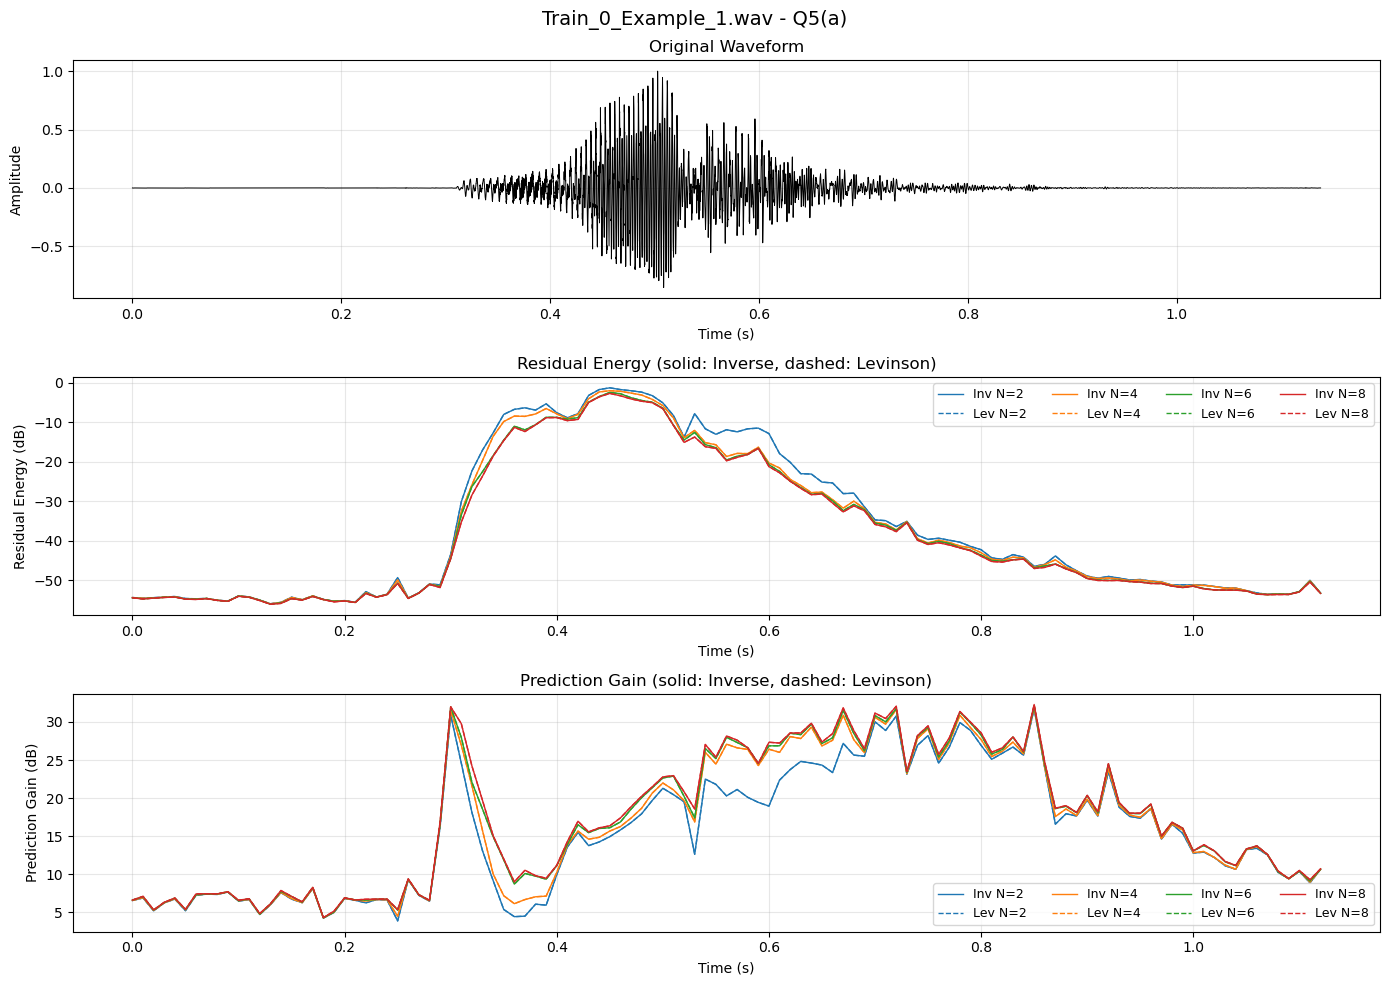

Train_0_Example_1.wav: 5(a) plotted
--------------------------------------------------------------------------------


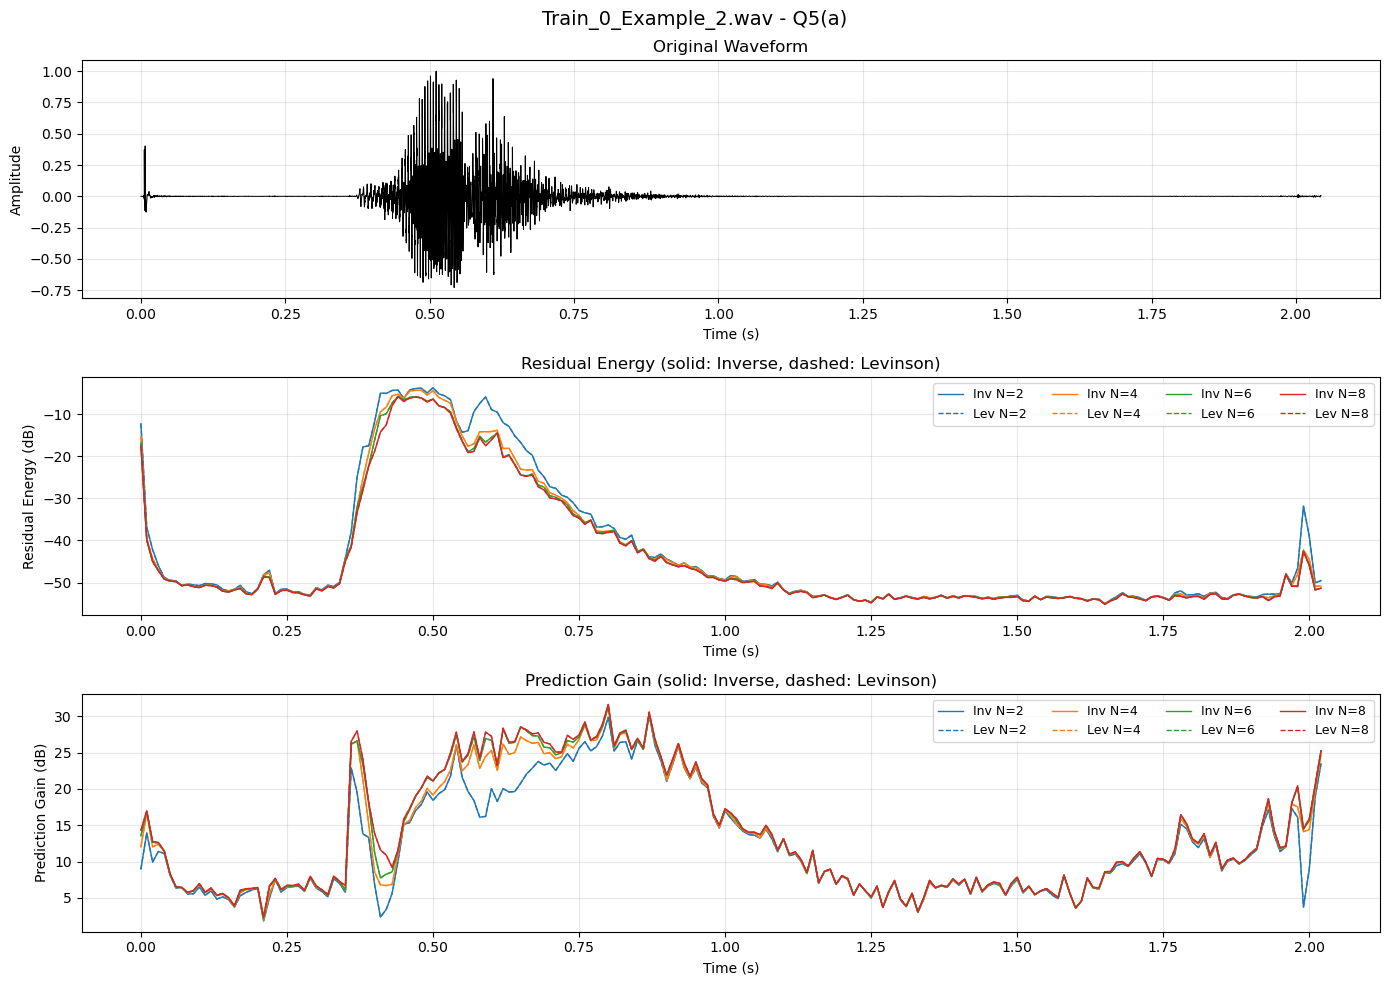

Train_0_Example_2.wav: 5(a) plotted
--------------------------------------------------------------------------------


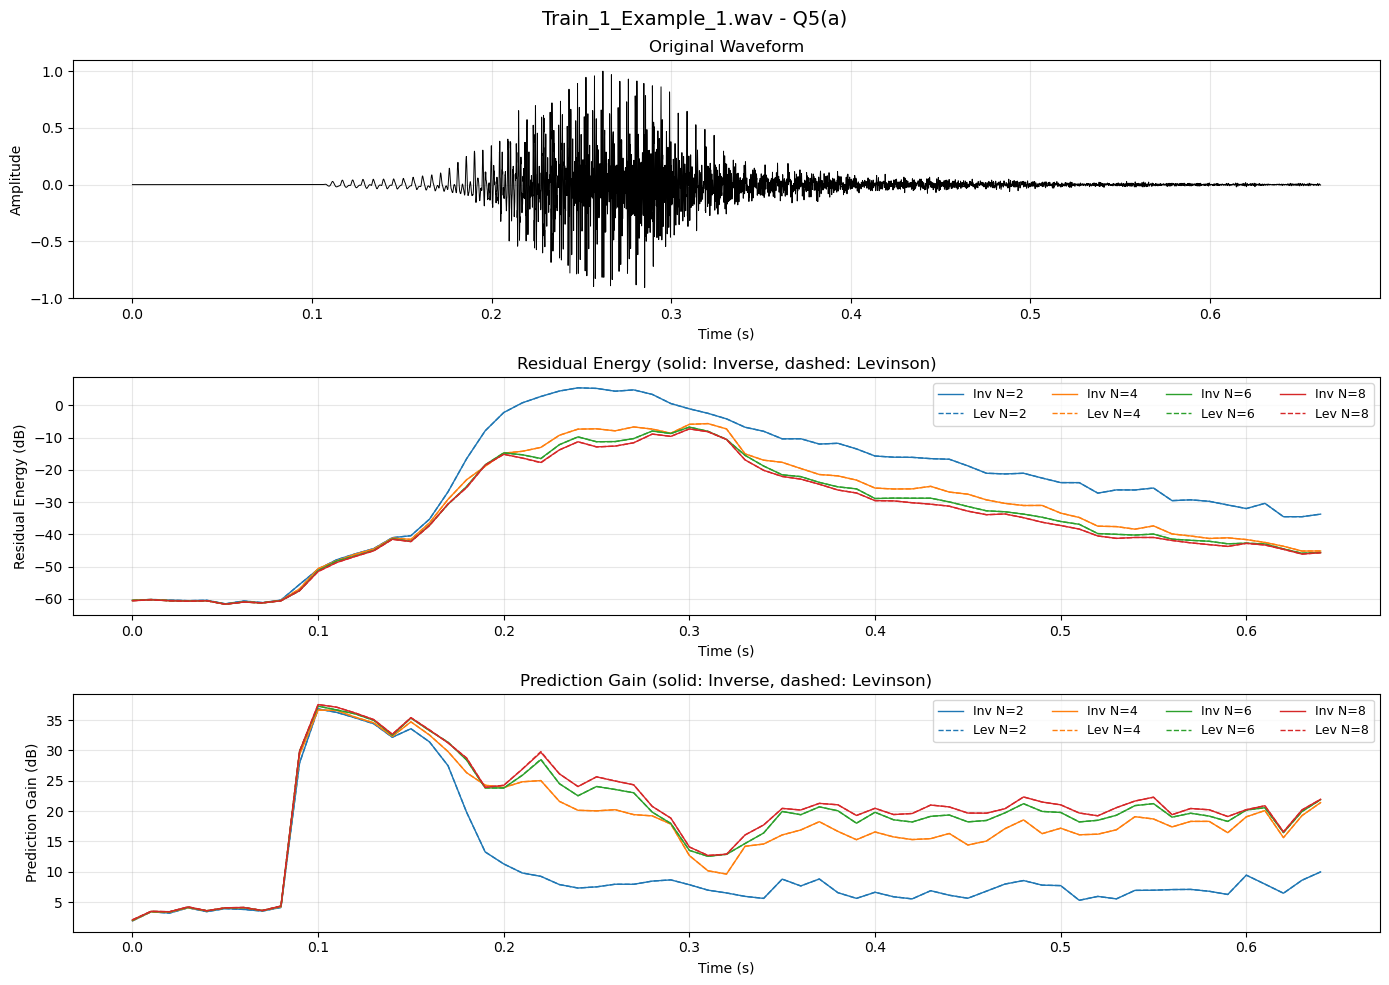

Train_1_Example_1.wav: 5(a) plotted
--------------------------------------------------------------------------------


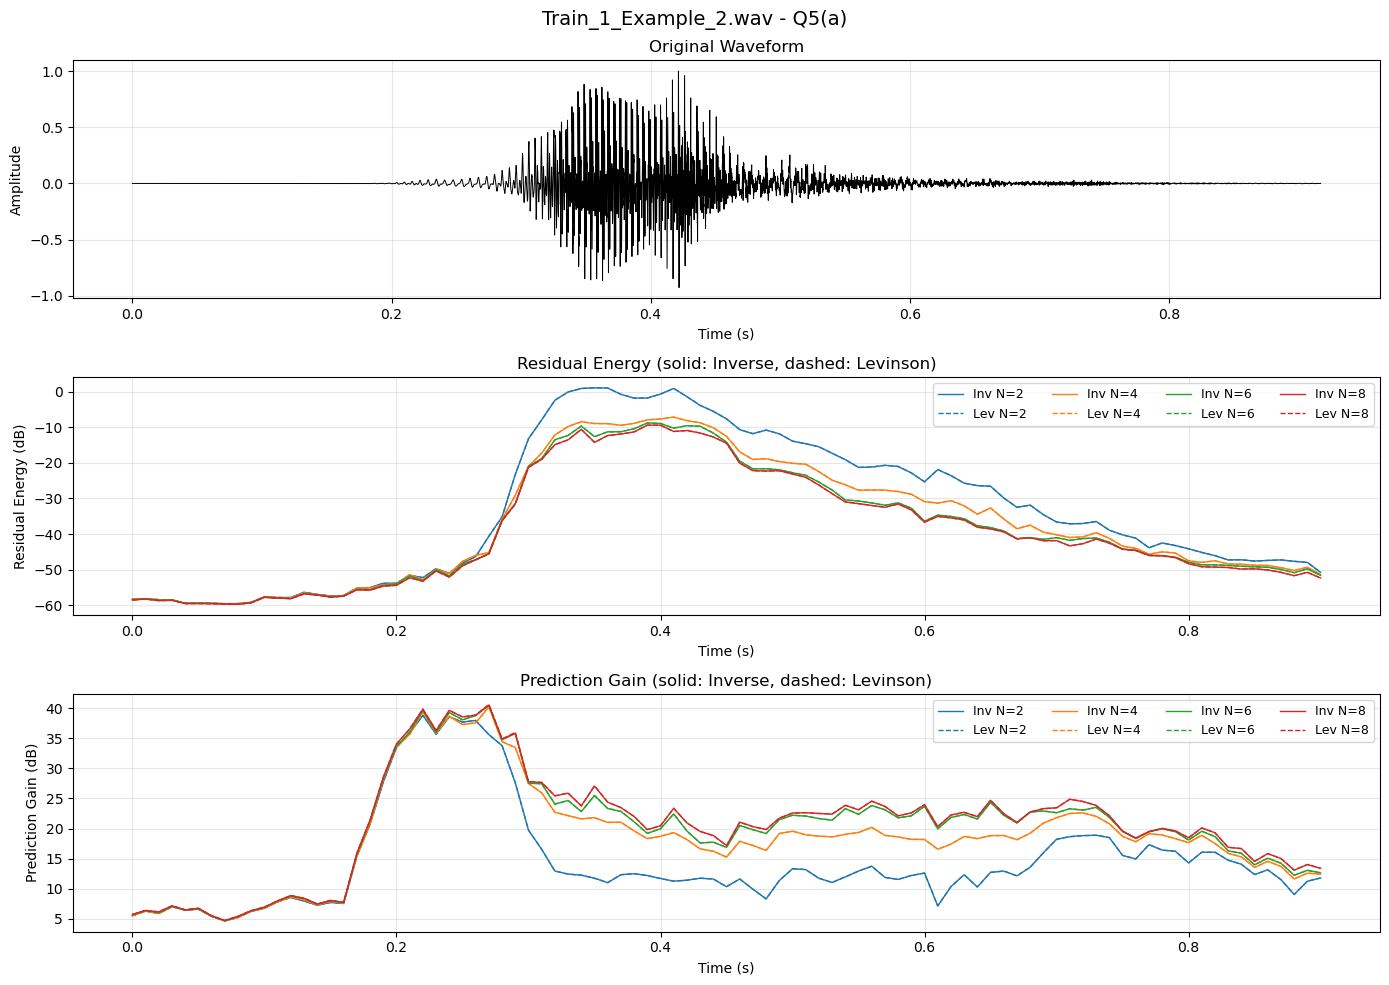

Train_1_Example_2.wav: 5(a) plotted
--------------------------------------------------------------------------------


In [31]:
for name, data in results.items():
    x = data['x']
    fs = data['fs']
    t = np.arange(len(x)) / fs
    ft = data['frame_times']

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
    fig.suptitle(f"{name} - Q5(a)", fontsize=14)

    axes[0].plot(t, x, color='black', linewidth=0.7)
    axes[0].set_title('Original Waveform')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(alpha=0.3)

    colors = {2: 'tab:blue', 4: 'tab:orange', 6: 'tab:green', 8: 'tab:red'}
    for N in LP_ORDERS_5A:
        axes[1].plot(ft, 10*np.log10(data['residual_energy']['inverse'][N] + EPS),
                     color=colors[N], linestyle='-', linewidth=1.0, label=f'Inv N={N}')
        axes[1].plot(ft, 10*np.log10(data['residual_energy']['levinson'][N] + EPS),
                     color=colors[N], linestyle='--', linewidth=1.0, label=f'Lev N={N}')
    axes[1].set_title('Residual Energy (solid: Inverse, dashed: Levinson)')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Residual Energy (dB)')
    axes[1].grid(alpha=0.3)
    axes[1].legend(ncol=4, fontsize=9)

    for N in LP_ORDERS_5A:
        axes[2].plot(ft, data['prediction_gain']['inverse'][N],
                     color=colors[N], linestyle='-', linewidth=1.0, label=f'Inv N={N}')
        axes[2].plot(ft, data['prediction_gain']['levinson'][N],
                     color=colors[N], linestyle='--', linewidth=1.0, label=f'Lev N={N}')
    axes[2].set_title('Prediction Gain (solid: Inverse, dashed: Levinson)')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('Prediction Gain (dB)')
    axes[2].grid(alpha=0.3)
    axes[2].legend(ncol=4, fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"{name}: 5(a) plotted")
    print('-' * 80)


## Question 5(b) - Reconstruction (Original Phase vs Random Phase)
This section shows reconstruction-quality trends and listening comparisons.


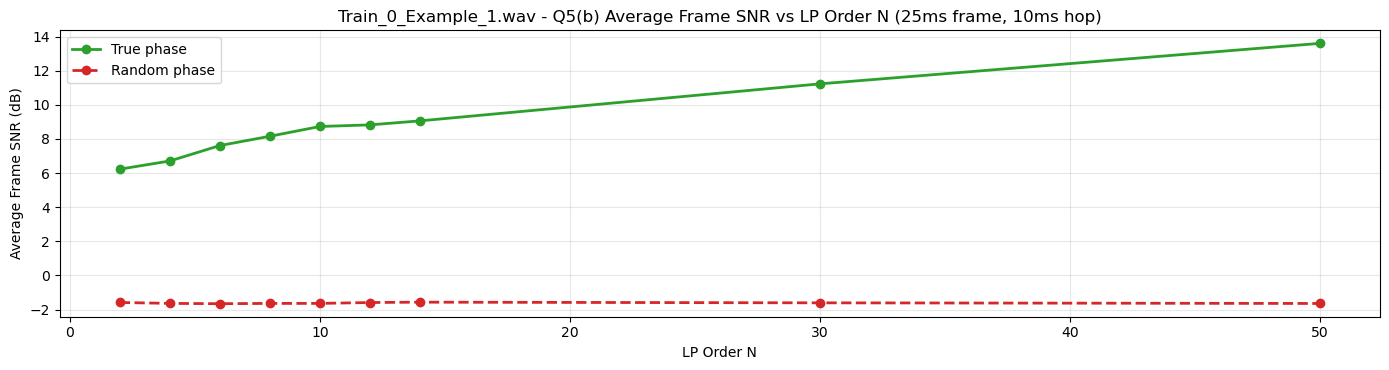

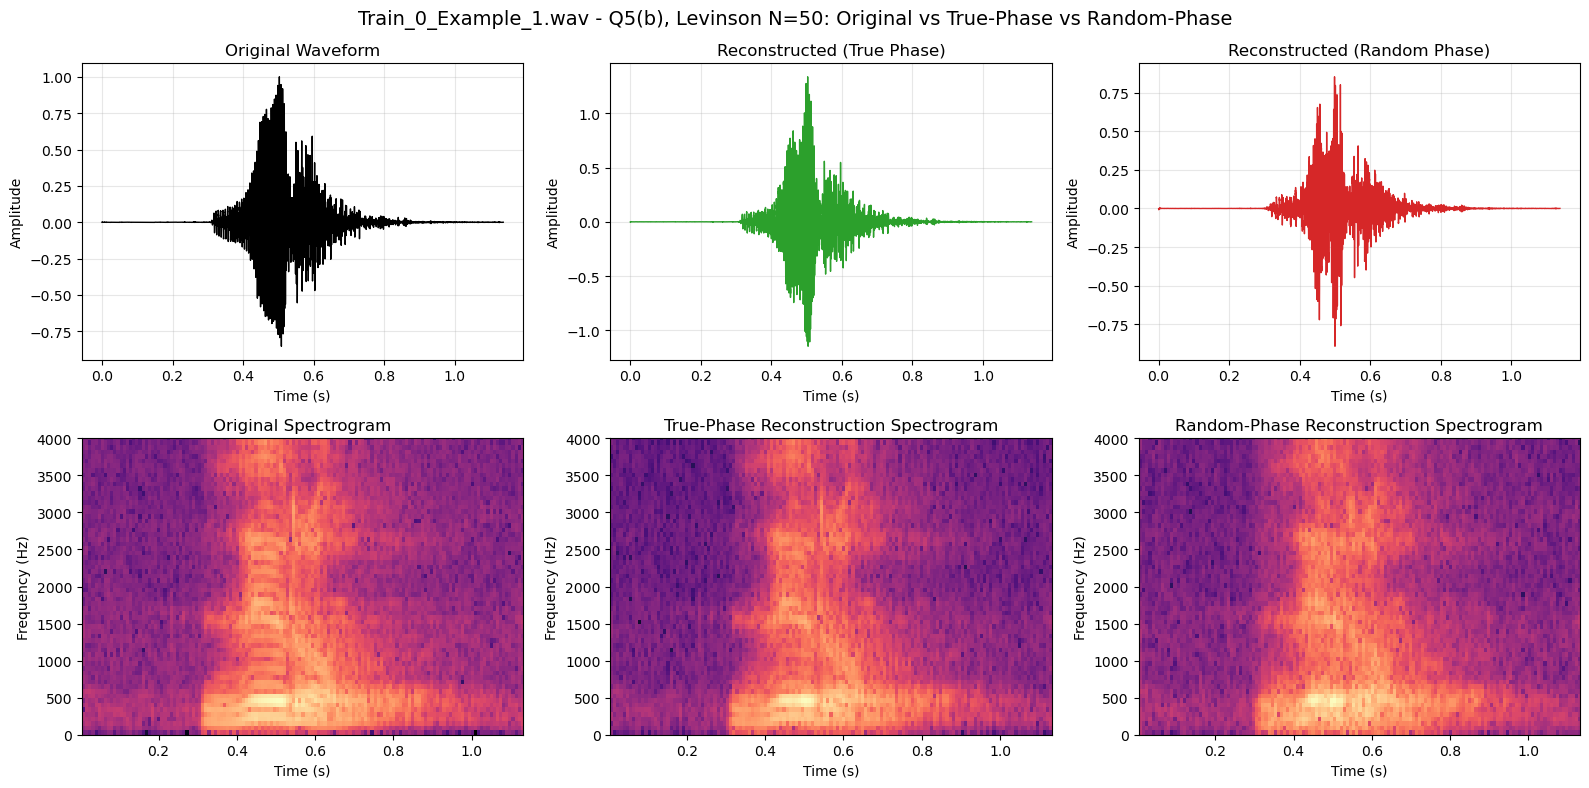

N=50: Global SNR true-phase=10.80 dB, random-phase=-2.13 dB, gap=12.93 dB
N=50: Average frame SNR true-phase=13.60 dB, random-phase=-1.64 dB
Listen (N=14): Original / True-phase / Random-phase


------------------------------------------------------------------------------------------


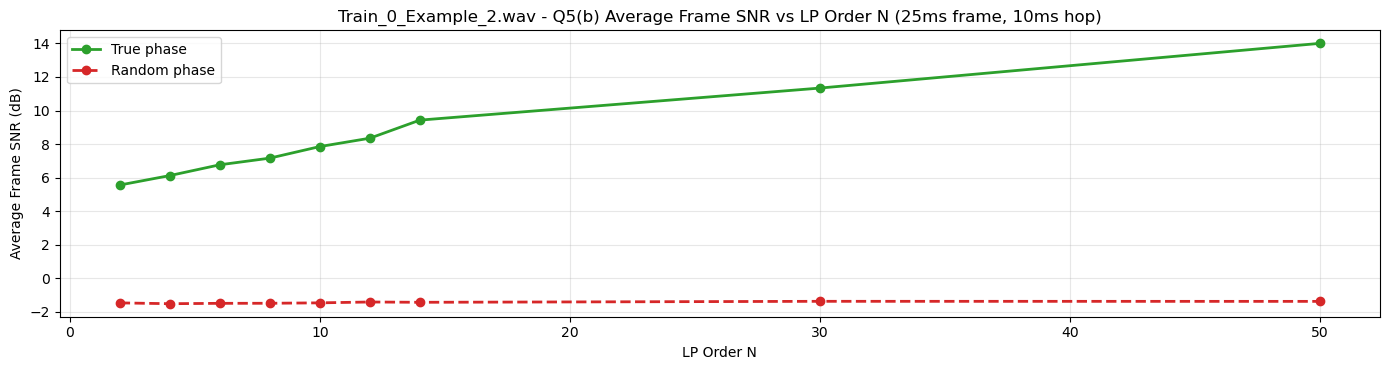

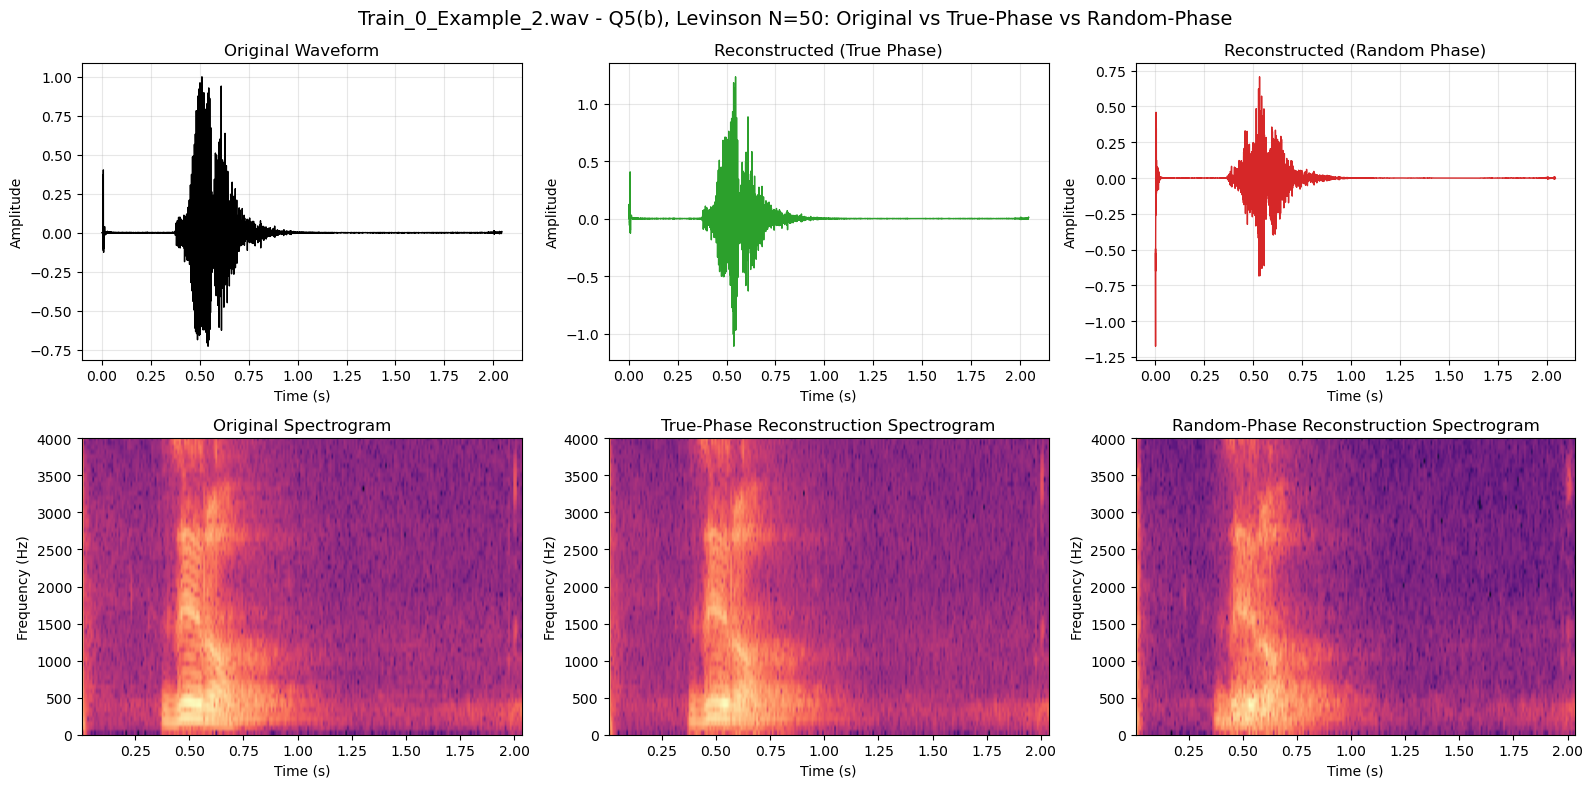

N=50: Global SNR true-phase=9.20 dB, random-phase=-1.68 dB, gap=10.88 dB
N=50: Average frame SNR true-phase=14.01 dB, random-phase=-1.38 dB
Listen (N=14): Original / True-phase / Random-phase


------------------------------------------------------------------------------------------


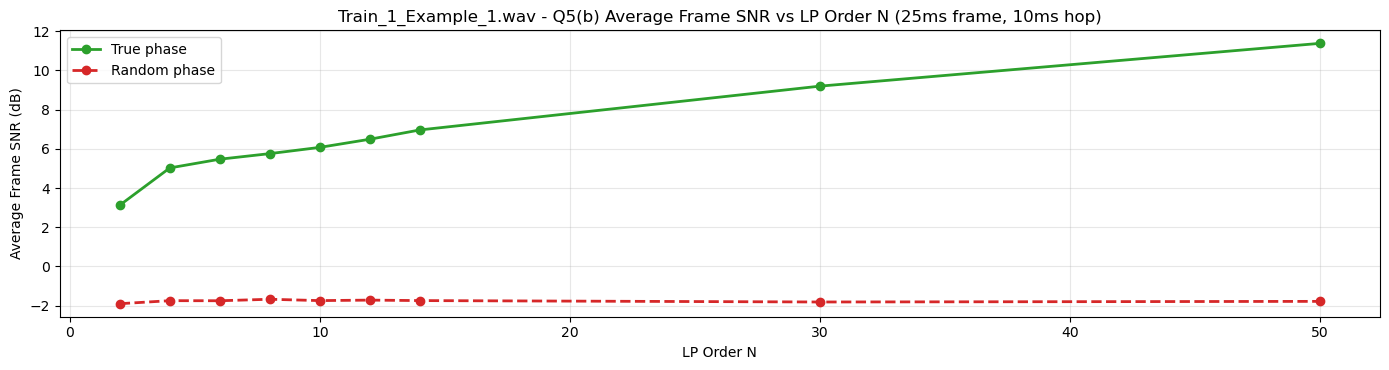

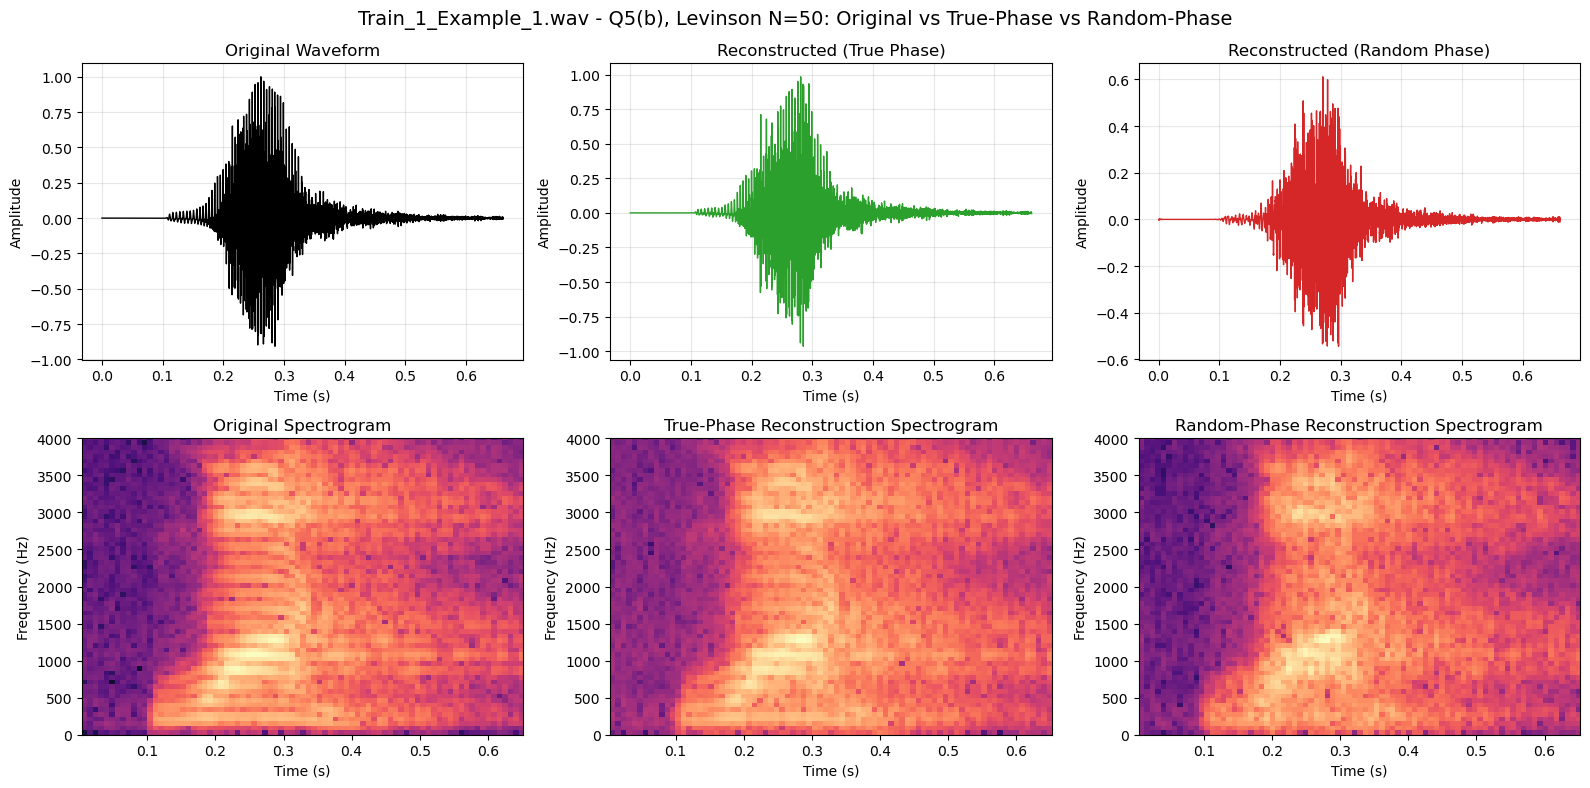

N=50: Global SNR true-phase=10.83 dB, random-phase=-1.15 dB, gap=11.98 dB
N=50: Average frame SNR true-phase=11.38 dB, random-phase=-1.78 dB
Listen (N=14): Original / True-phase / Random-phase


------------------------------------------------------------------------------------------


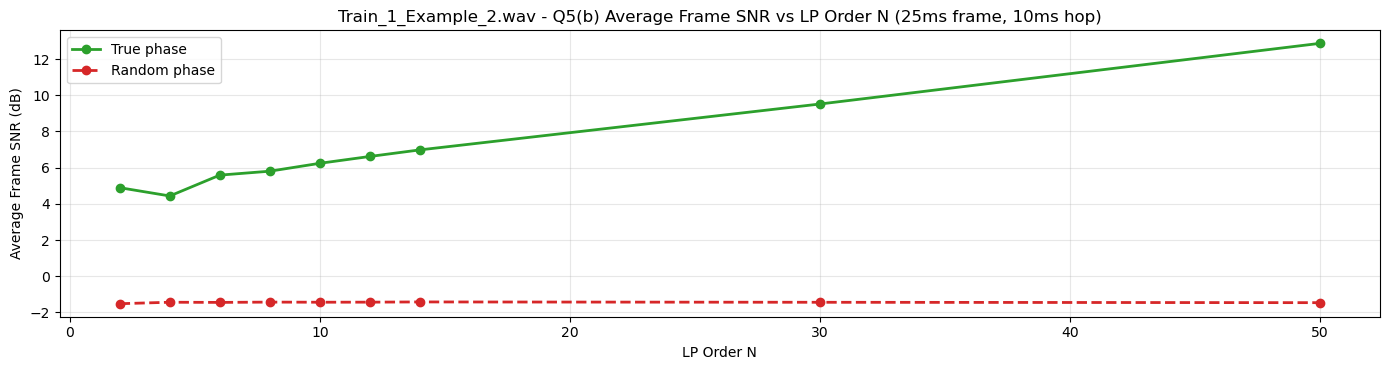

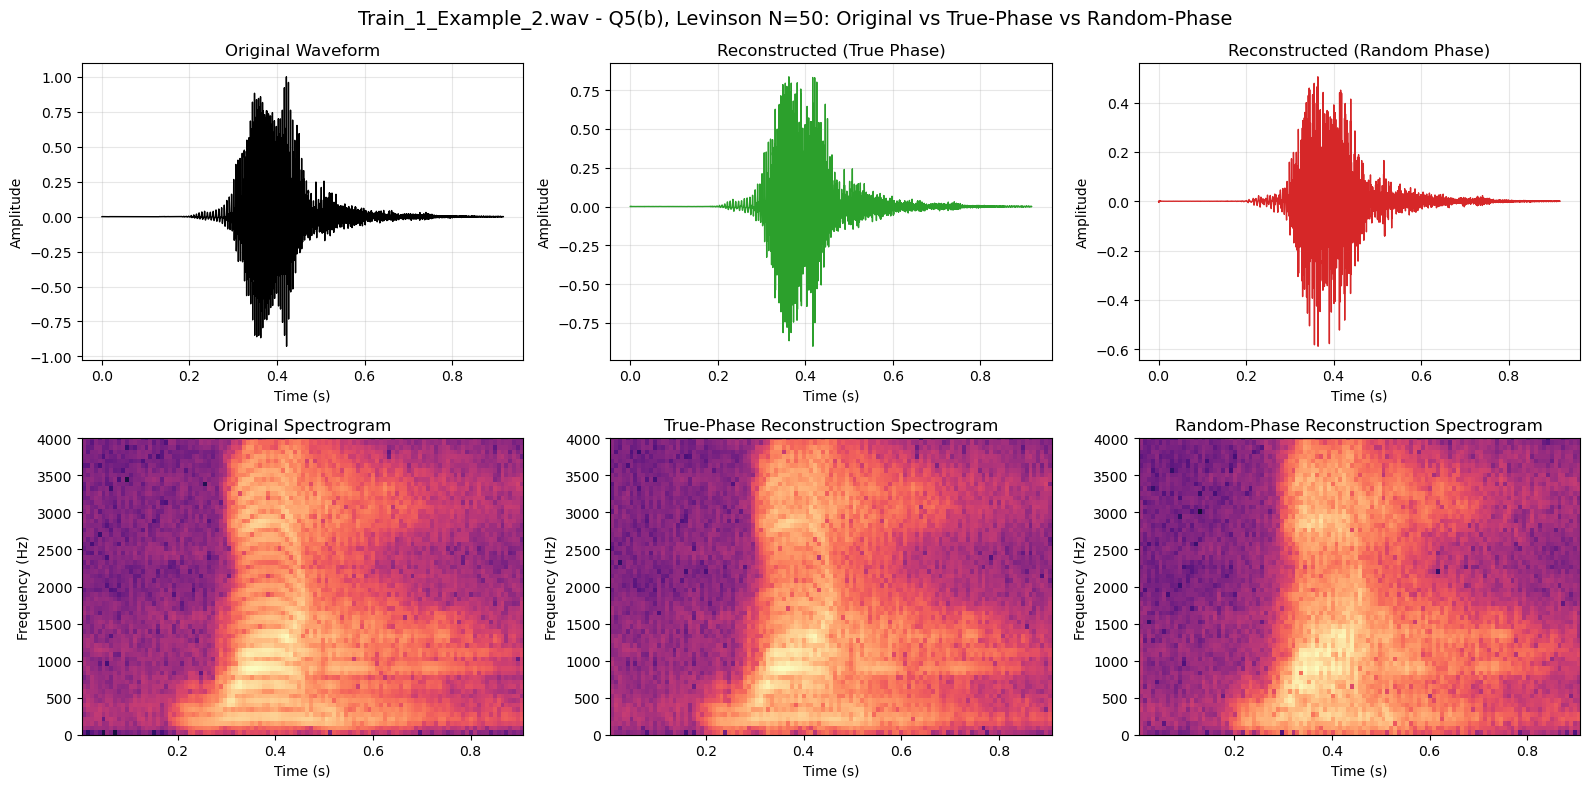

N=50: Global SNR true-phase=11.32 dB, random-phase=-1.65 dB, gap=12.98 dB
N=50: Average frame SNR true-phase=12.87 dB, random-phase=-1.46 dB
Listen (N=14): Original / True-phase / Random-phase


------------------------------------------------------------------------------------------


In [34]:
for name, data in results.items():
    x = data['x']
    fs = data['fs']

    def avg_frame_snr(x_ref, x_est, frame_len, hop):
        n = min(len(x_ref), len(x_est))
        x_ref = x_ref[:n]
        x_est = x_est[:n]
        if n < frame_len:
            return np.nan
        n_frames = (n - frame_len) // hop + 1
        vals = []
        for i in range(n_frames):
            s = i * hop
            xr = x_ref[s:s+frame_len]
            xe = x_est[s:s+frame_len]
            vals.append(10*np.log10((np.sum(xr**2)+EPS)/(np.sum((xr-xe)**2)+EPS)))
        return float(np.mean(vals))

    frame_len = int(round(FRAME_MS * fs))
    hop = int(round(HOP_MS * fs))

    # SNR vs N (Average frame SNR)
    avg_snr_true = []
    avg_snr_rand = []
    for N in LP_ORDERS_5B:
        y_t = data['recon_5b']['orig'][N]
        y_r = data['recon_5b']['rand'][N]
        avg_snr_true.append(avg_frame_snr(x, y_t, frame_len, hop))
        avg_snr_rand.append(avg_frame_snr(x, y_r, frame_len, hop))

    plt.figure(figsize=(14, 3.8))
    plt.plot(LP_ORDERS_5B, avg_snr_true, 'o-', color='tab:green', linewidth=2, label='True phase')
    plt.plot(LP_ORDERS_5B, avg_snr_rand, 'o--', color='tab:red', linewidth=2, label='Random phase')
    plt.title(f'{name} - Q5(b) Average Frame SNR vs LP Order N (25ms frame, 10ms hop)')
    plt.xlabel('LP Order N')
    plt.ylabel('Average Frame SNR (dB)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Detailed visualization at one order
    N_show = 50
    y_true = data['recon_5b']['orig'][N_show]      # reconstructed with true/original phase
    y_rand = data['recon_5b']['rand'][N_show]      # reconstructed with random phase

    # n_show = min(int(0.25 * fs), len(x), len(y_true), len(y_rand))
    n_show = len(x)
    ts = np.arange(n_show) / fs

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle(f'{name} - Q5(b), Levinson N={N_show}: Original vs True-Phase vs Random-Phase', fontsize=14)

    axes[0, 0].plot(ts, x[:n_show], color='black', linewidth=1.0)
    axes[0, 0].set_title('Original Waveform')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Amplitude')
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(ts, y_true[:n_show], color='tab:green', linewidth=1.0)
    axes[0, 1].set_title('Reconstructed (True Phase)')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Amplitude')
    axes[0, 1].grid(alpha=0.3)

    axes[0, 2].plot(ts, y_rand[:n_show], color='tab:red', linewidth=1.0)
    axes[0, 2].set_title('Reconstructed (Random Phase)')
    axes[0, 2].set_xlabel('Time (s)')
    axes[0, 2].set_ylabel('Amplitude')
    axes[0, 2].grid(alpha=0.3)

    axes[1, 0].specgram(x, NFFT=256, Fs=fs, noverlap=128, cmap='magma')
    axes[1, 0].set_ylim(0, fs/4)
    axes[1, 0].set_title('Original Spectrogram')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].set_ylabel('Frequency (Hz)')

    axes[1, 1].specgram(y_true, NFFT=256, Fs=fs, noverlap=128, cmap='magma')
    axes[1, 1].set_ylim(0, fs/4)
    axes[1, 1].set_title('True-Phase Reconstruction Spectrogram')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Frequency (Hz)')

    axes[1, 2].specgram(y_rand, NFFT=256, Fs=fs, noverlap=128, cmap='magma')
    axes[1, 2].set_ylim(0, fs/4)
    axes[1, 2].set_title('Random-Phase Reconstruction Spectrogram')
    axes[1, 2].set_xlabel('Time (s)')
    axes[1, 2].set_ylabel('Frequency (Hz)')

    plt.tight_layout()
    plt.show()

    idx_show = LP_ORDERS_5B.index(N_show)
    so = data['snr_orig_5b'][idx_show]
    sr = data['snr_rand_5b'][idx_show]
    print(f'N={N_show}: Global SNR true-phase={so:.2f} dB, random-phase={sr:.2f} dB, gap={so-sr:.2f} dB')
    print(f'N={N_show}: Average frame SNR true-phase={avg_snr_true[idx_show]:.2f} dB, random-phase={avg_snr_rand[idx_show]:.2f} dB')

    print('Listen (N=14): Original / True-phase / Random-phase')
    display(Audio(x, rate=fs))
    display(Audio(y_true, rate=fs))
    display(Audio(y_rand, rate=fs))
    print('-' * 90)


## Question 6 - Power-Law LP Spectrum Fitting (q = 1,2,3)

Steps implemented:
1. Pick one voiced and one unvoiced frame from 5(a) residual energy (low = voiced, high = unvoiced).
2. Compute true PSD `Sxx = |STFT|^2` for both frames.
3. For each `q in {1,2,3}`:
   - compress spectrum `Sxx^(1/q)`
   - IDTFT to modified autocorrelation
   - solve Yule-Walker
   - compute AR spectrum and then raise to power `q`
4. Plot true vs estimated PSD for voiced/unvoiced frames.


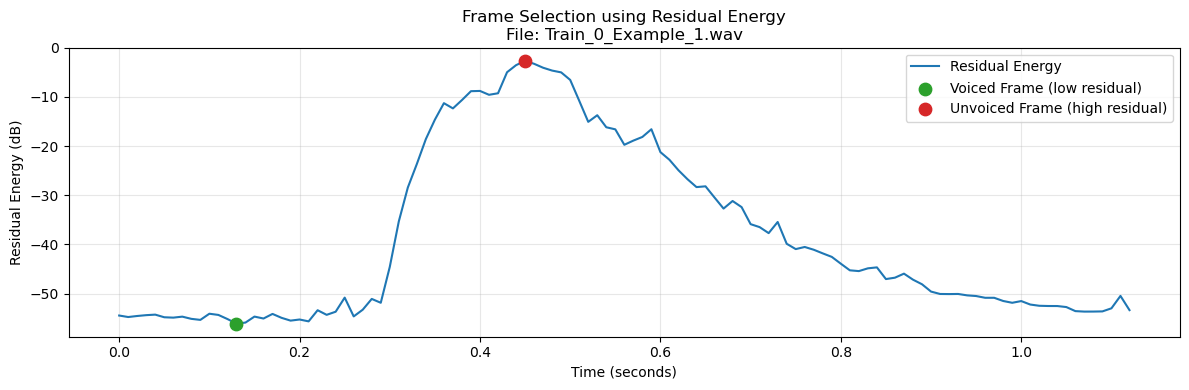

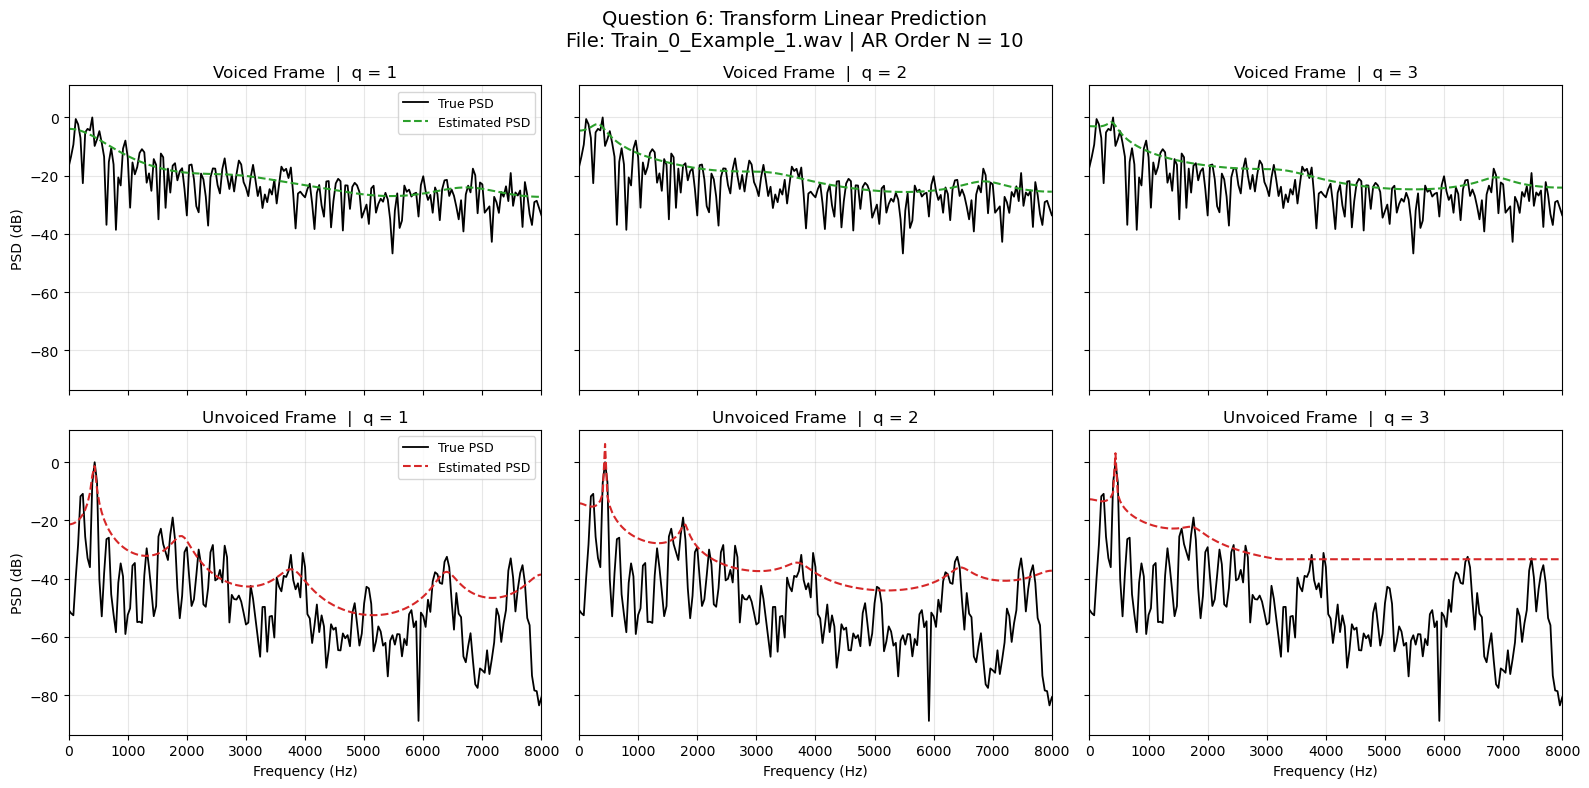

Selected frame indices:
Voiced frame index   : 13
Unvoiced frame index : 45


In [39]:
# ---------------- Question 6 : Frame Selection + PSD Plots ----------------

PART6_FILE = AUDIO_FILES[0].name
PART6_ORDER = 10
Q_LIST = [1, 2, 3]

# Residual energy from Q5 (Levinson, N=8)
res_ref = results[PART6_FILE]['residual_energy']['levinson'][8]

idx_voiced = int(np.argmin(res_ref))      # low residual
idx_unvoiced = int(np.argmax(res_ref))    # high residual

fs, x = load_audio(DATA_DIR / PART6_FILE)

frame_len = int(round(FRAME_MS * fs))
hop = int(round(HOP_MS * fs))
frames, starts = frame_signal(x, frame_len, hop)

win = np.hamming(frame_len)


# ================= Frame Selection Plot =================

time_axis = np.arange(len(res_ref)) * (hop / fs)

plt.figure(figsize=(12, 4))

plt.plot(
    time_axis,
    10*np.log10(res_ref + EPS),
    color='tab:blue',
    linewidth=1.5,
    label='Residual Energy'
)

plt.scatter(
    time_axis[idx_voiced],
    10*np.log10(res_ref[idx_voiced] + EPS),
    color='tab:green',
    s=80,
    zorder=3,
    label='Voiced Frame (low residual)'
)

plt.scatter(
    time_axis[idx_unvoiced],
    10*np.log10(res_ref[idx_unvoiced] + EPS),
    color='tab:red',
    s=80,
    zorder=3,
    label='Unvoiced Frame (high residual)'
)

plt.title(
    f'Frame Selection using Residual Energy\nFile: {PART6_FILE}'
)

plt.xlabel('Time (seconds)')
plt.ylabel('Residual Energy (dB)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ================= Transform LP Function =================

def transform_lp(frame, fs, order, q):

    xw = frame * win
    xw = xw / np.sqrt(np.sum(win**2) + EPS)

    X = np.fft.fft(xw)
    Sxx = np.abs(X)**2

    # Normalize for stability
    Sxx = Sxx / (np.max(Sxx) + EPS)

    S_q = Sxx ** q

    r_q = np.real(np.fft.ifft(S_q))

    a, err = yw_from_acf(r_q, order)

    A = np.fft.fft(np.concatenate(([1.0], a)), n=len(Sxx))
    S_q_hat = err / (np.abs(A)**2 + EPS)

    S_hat = (np.maximum(S_q_hat, EPS)) ** (1.0 / q)

    f = np.fft.rfftfreq(len(Sxx), 1/fs)
    half = len(f)

    return f, Sxx[:half], S_hat[:half]


frame_voiced = frames[idx_voiced]
frame_unvoiced = frames[idx_unvoiced]


# ================= PSD Comparison Plots =================

fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 8),
    sharex=True,
    sharey=True
)

fig.suptitle(
    f'Question 6: Transform Linear Prediction\n'
    f'File: {PART6_FILE} | AR Order N = {PART6_ORDER}',
    fontsize=14
)


for col, q in enumerate(Q_LIST):

    # ---------- Voiced ----------
    f_v, S_true_v, S_hat_v = transform_lp(
        frame_voiced, fs, PART6_ORDER, q
    )

    ax = axes[0, col]

    ax.plot(
        f_v,
        10*np.log10(S_true_v + EPS),
        color='black',
        linewidth=1.3,
        label='True PSD'
    )

    ax.plot(
        f_v,
        10*np.log10(S_hat_v + EPS),
        '--',
        color='tab:green',
        linewidth=1.5,
        label='Estimated PSD'
    )

    ax.set_title(f'Voiced Frame  |  q = {q}')
    ax.grid(alpha=0.3)

    if col == 0:
        ax.set_ylabel('PSD (dB)')
        ax.legend(fontsize=9)


    # ---------- Unvoiced ----------
    f_u, S_true_u, S_hat_u = transform_lp(
        frame_unvoiced, fs, PART6_ORDER, q
    )

    ax = axes[1, col]

    ax.plot(
        f_u,
        10*np.log10(S_true_u + EPS),
        color='black',
        linewidth=1.3,
        label='True PSD'
    )

    ax.plot(
        f_u,
        10*np.log10(S_hat_u + EPS),
        '--',
        color='tab:red',
        linewidth=1.5,
        label='Estimated PSD'
    )

    ax.set_title(f'Unvoiced Frame  |  q = {q}')
    ax.grid(alpha=0.3)

    if col == 0:
        ax.set_ylabel('PSD (dB)')
        ax.legend(fontsize=9)


for ax in axes[1, :]:
    ax.set_xlabel('Frequency (Hz)')
    ax.set_xlim(0, fs/2)


plt.tight_layout()
plt.show()


print("Selected frame indices:")
print("Voiced frame index   :", idx_voiced)
print("Unvoiced frame index :", idx_unvoiced)